In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import bioviper as bv

/home/sb611/.conda/envs/evcouplings_new/lib/python3.11/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [18]:
ramr_wt = "MVARPKSEDKKQALLEAATQAIAQSGIAASTAVIARNAGVAEGTLFRYFATKDELINTLYLHLKQDLCQSMIMELDRSITDAKMMTRFIWNSYISWGLNHPARHRAIRQLAVSEKLTKETEQRADDMFPELRDLCHRSVLMVFMSDEYRAFGDGLFLALAETTMDFAARDPARAGEYIALGFEAMWRALTREEQ"
print("Sequence length:", len(ramr_wt))

ramr_ep = pd.read_csv("../raw_data/HLTLH_SALTY_dOelsnitz_2025/EP library.df_output_all.csv", index_col=0)
ramr_ss = pd.read_csv("../raw_data/HLTLH_SALTY_dOelsnitz_2025/SS library.df_output_all.csv", index_col=0)

ramr_dataset = pd.concat([ramr_ep, ramr_ss], axis=0)

print("Dataset size:", len(ramr_dataset))

Sequence length: 194
Dataset size: 150315


In [24]:
ramr_dataset['mutant'] = ramr_dataset['substitutions']
ramr_dataset.set_index("substitutions", inplace=True)

In [36]:
ramr_dataset_filt = ramr_dataset.loc[['nan' not in str(i) and '*' not in str(i) for i in ramr_dataset.index]]

In [50]:
print([i for i in ramr_dataset_filt.columns if '1-DIQ' in i])

['log_ginf_1-DIQ', 'log_ginf_1-DIQ_err', 'log_ec50_1-DIQ', 'log_ec50_1-DIQ_err', 'spec_1-DIQ', 'spec_1-DIQ_err', 'GP_log_g500_1-DIQ', 'GP_log_g500_1-DIQ_err', 'log_g_32_1-DIQ', 'log_g_32_1-DIQ_err', 'GP_spec_1-DIQ', 'GP_spec_1-DIQ_err']


In [53]:
ramr_dataset_filt['DMS_score'] = ramr_dataset_filt['log_ginf_1-DIQ'] - ramr_dataset_filt['log_g0']

/tmp/ipykernel_1520770/2225526350.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ramr_dataset_filt['DMS_score'] = ramr_dataset_filt['log_ginf_1-DIQ'] - ramr_dataset_filt['log_g0']


In [39]:
def get_variant(reference, mutations, start_index=1):

    if isinstance(reference, (str, np.str_)):
        reference = np.array(list(reference))
        return_as_string = True
    
    variant = reference.copy()
    for mut in mutations:
        if mut!='WT':
            pos = int(mut[1:-1])-start_index
            variant[pos] = mut[-1]

    if return_as_string:
        return ''.join(variant)
    else:   
        return variant

ramr_dataset_filt['mutated_sequence'] = [get_variant(ramr_wt, str(_id).split(':')) for _id in ramr_dataset_filt.mutant]

/tmp/ipykernel_1520770/1608521507.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ramr_dataset_filt['mutated_sequence'] = [get_variant(ramr_wt, str(_id).split(':')) for _id in ramr_dataset_filt.mutant]


In [55]:
ramr_dataset_filt.to_csv("../processed_data/HTHTR_SALTY_dOelsnitz_2025/HTHTR_SALTY_dOelsnitz_2025_1DIQ_log_fold_induction.csv")

In [57]:
ramr_dataset_filt.to_csv("/n/groups/marks/users/sam/SpecificityStudio/DMS_assays/HTHTR_SALTY_dOelsnitz_2025_1DIQ_log_fold_induction.csv")

(array([4.0000e+00, 9.0000e+00, 2.5000e+01, 6.1000e+01, 1.3100e+02,
        2.8600e+02, 1.1090e+03, 6.2360e+03, 1.0198e+04, 9.6130e+03,
        1.2714e+04, 2.0339e+04, 2.2932e+04, 1.8819e+04, 1.5035e+04,
        1.1782e+04, 7.1260e+03, 2.5640e+03, 4.3900e+02, 1.5000e+01]),
 array([1.28604 , 1.459366, 1.632692, 1.806018, 1.979344, 2.15267 ,
        2.325996, 2.499322, 2.672648, 2.845974, 3.0193  , 3.192626,
        3.365952, 3.539278, 3.712604, 3.88593 , 4.059256, 4.232582,
        4.405908, 4.579234, 4.75256 ]),
 <BarContainer object of 20 artists>)

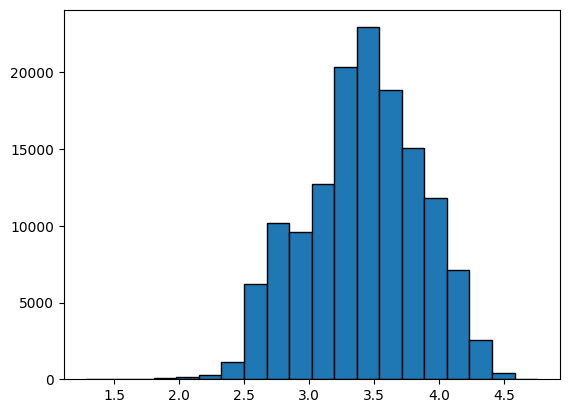

In [47]:
plt.hist(ramr_dataset_filt['GP_log_g500_1-DIQ'], bins=20, ec='k')

In [43]:
ramr_dataset_filt.columns

Index(['total_counts', 'long_read_count', 'log_g0', 'log_g0_err',
       'log_ginf_1-DIQ', 'log_ginf_1-DIQ_err', 'log_ec50_1-DIQ',
       'log_ec50_1-DIQ_err', 'log_ginf_1R-TIQ', 'log_ginf_1R-TIQ_err',
       'log_ec50_1R-TIQ', 'log_ec50_1R-TIQ_err', 'log_ginf_1S-TIQ',
       'log_ginf_1S-TIQ_err', 'log_ec50_1S-TIQ', 'log_ec50_1S-TIQ_err',
       'spec_1-DIQ', 'spec_1-DIQ_err', 'spec_1R-TIQ', 'spec_1R-TIQ_err',
       'spec_1S-TIQ', 'spec_1S-TIQ_err', 'mean_log_ec50', 'mean_log_ec50_err',
       'GP_log_g500_1-DIQ', 'GP_log_g500_1-DIQ_err', 'GP_log_g500_1R-TIQ',
       'GP_log_g500_1R-TIQ_err', 'GP_log_g500_1S-TIQ',
       'GP_log_g500_1S-TIQ_err', 'GP_log_g0', 'GP_log_g0_err',
       'log_g_32_1-DIQ', 'log_g_32_1-DIQ_err', 'log_g_32_1R-TIQ',
       'log_g_32_1R-TIQ_err', 'log_g_32_1S-TIQ', 'log_g_32_1S-TIQ_err',
       'GP_spec_1-DIQ', 'GP_spec_1-DIQ_err', 'GP_spec_1R-TIQ',
       'GP_spec_1R-TIQ_err', 'GP_spec_1S-TIQ', 'GP_spec_1S-TIQ_err',
       'mean_log_g_32', 'mean_log_g_32_err'